In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.metrics import confusion_matrix

In [2]:
# Load dataset
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv('iris/iris.data', header=None, names=columns)
df['species'] = df['class'].astype('category').cat.codes
x = df['sepal_width'].values
y = df['species'].values

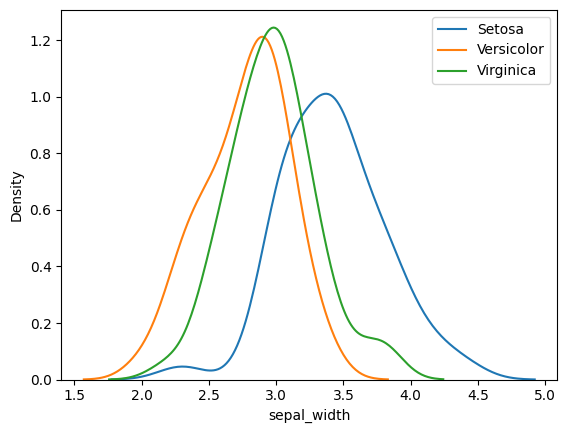

In [3]:
# Data visualization
y0 = df[df['species'] == 0]['sepal_width']
y1 = df[df['species'] == 1]['sepal_width']
y2 = df[df['species'] == 2]['sepal_width']
sns.kdeplot(y0, label='Setosa')
sns.kdeplot(y1, label='Versicolor')
sns.kdeplot(y2, label='Virginica')
plt.legend()
plt.show()

In [4]:
# Data splitting
n = len(x)
train_Fraction = 0.75
sample = np.random.uniform(size = n) < train_Fraction
x_train = x[sample]
y_train = y[sample]
x_test = x[~sample]
y_test = y[~sample]

In [5]:
# Model Training
best_acc = 0
best_threshold = (0, 0)

for i in np.sort(x_train):
    for j in np.sort(x_train):
        if i >= j:
            continue
        # Prediction logic: [min, i) -> 1, [i, j) -> 2, [j, max] -> 0
        y_pred = np.where(x_train < i, 1, np.where(x_train < j, 2, 0))
        acc = (y_pred == y_train).mean()
        if acc >= best_acc:
            best_acc = acc
            best_threshold = (i, j)
            
threshold = best_threshold

In [6]:
# Test model on test set
test_pred = np.where(x_test < threshold[0], 1, np.where(x_test < threshold[1], 2, 0))
test_acc = (test_pred == y_test).mean()
print(test_acc)

0.5882352941176471


Confusion Matrix: 
 [[ 8  0  1]
 [ 3 11  2]
 [ 4  4  1]]


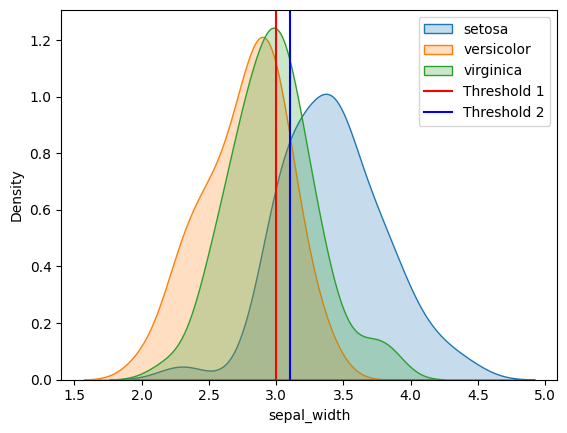

In [7]:
# Report results
cm = confusion_matrix(y_test, test_pred)
print("Confusion Matrix: \n", cm)

sns.kdeplot(y0, label='setosa', fill=True)
sns.kdeplot(y1, label='versicolor', fill=True)
sns.kdeplot(y2, label='virginica', fill=True)
plt.axvline(threshold[0], color='red', label='Threshold 1')
plt.axvline(threshold[1], color='blue', label='Threshold 2')
plt.legend()
plt.show()

In [8]:
# Load Dataset
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame
subset = df[df['MedHouseVal'] < 5].copy()
x = subset['MedHouseVal'].values
y = subset['MedInc'].values

In [ ]:
# A class for regression through the origin
class OriginRegressor:
    def __init__(self, x_array, y_array):
        self.x = x_array
        self.y = y_array
        self.slope = None
        self.prediction = None
    
    def fit(self, norm_x, norm_y):
        # Normalize x and y if specified
        self.x = (self.x - self.x.mean()) / self.x.std() if norm_x else self.x
        self.y = (self.y - self.y.mean()) / self.y.std() if norm_y else self.y
        self.slope = np.sum(self.x * self.y) / np.sum(self.x ** 2)
        self.prediction = self.slope * self.x
        return self.slope
    
    def rmse(self):
        # Calculate Root Mean Squared Error
        mse = np.mean((self.prediction - self.y) ** 2)
        return np.sqrt(mse)


In [ ]:
# Regression through the origin for the California housing dataset
model = OriginRegressor(x, y)
print("Slope:", model.fit(norm_x=True, norm_y=True))
print("RMSE:", model.rmse())

Slope: 0.998248950880053
RMSE: 0.0983663436651059
Least Squares Error: 0.0967593756604172


For a regression through the origin $$Y = bX + e$$
the Residual Sum of Squares is:$$RSS(b) = \sum_{i=1}^{n} (Y_i - bX_i)^2$$
If the predictor $X$ is constant at $1$, RSS will be:$$RSS(b) = \sum_{i=1}^{n} (Y_i - b)^2$$
To do the regression through the origin, we need to minimize the RSS.
So we take the derivative with respect to $b$ and let it be zero:$$\frac{d}{db}\sum_{i=1}^{n} (Y_i - b)^2 = -2 \sum_{i=1}^{n} (Y_i - b) = 0$$
which means $$\sum_{i=1}^{n} (Y_i - b) = 0$$
And because $b$ is a constant,$$\sum_{i=1}^{n} Y_i = \sum_{i=1}^{n} b = nb$$
So $$b = \frac{1}{n} \sum_{i=1}^{n} Y_i = \bar{Y}$$

The conversion formula between Farenheit and Calcius is:$$X = 1.8Z + 32$$
For the first regression through the origin $$Y = bX + e$$ $$ b = \frac{\sum X_i Y_i}{\sum X_i^2} $$
For the second regression through the origin $$Y = cZ + e$$ $$ c = \frac{\sum Z_i Y_i}{\sum Z_i^2} $$
Convert $X_i$ to $Z_i$ in $b$ $$ b = \frac{\sum X_i Y_i}{\sum X_i^2} = \frac{\sum (1.8Z_i + 32) Y_i}{\sum (1.8Z_i + 32)^2} = \frac{\sum (1.8Z_i Y_i + 32 Y_i)}{\sum (1.8^2 Z_i^2 + 2*1.8*32 Z_i + 32^2)} = \frac{\frac{c}{1.8}+\frac{32\sum Y_i}{1.8^2 \sum Z_i^2}}{1 + \frac{2*32 \sum Z_i}{1.8 \sum Z_i^2} + \frac{32^2}{1.8 \sum Z_i^2}}$$
Because the conversion formula contains an interpret(+32), the relationship between b and c is not linear and depends on the data.

But if we ignore the intercept, so consider $$ X \approx 1.8Z$$
Then $$ b = \frac{\sum X_i Y_i}{\sum X_i^2} \approx \frac{\sum (1.8Z_i) Y_i}{\sum (1.8Z_i)^2} = \frac{c}{1.8}$$